# Test Set Challenge Evaluation

This notebook evaluates the best performing models on the **VisDrone2019 test-challenge set**.

## Required Inputs

To run this notebook, you need to add the following as inputs via **+ Add Input** in the Kaggle notebook editor:

| Input | Type | What to add |
|---|---|---|
| VisDrone Dataset | Dataset | The same VisDrone dataset used in training |
| YOLOv11s + L2 weights | Dataset or uploaded file | Upload `yolo11s_l2_export.zip` and extract, or upload `best.pt` directly |
| YOLOv11s weights | Dataset or uploaded file | Upload `baseline_yolo11s_export.zip` and extract, or upload `best.pt` directly |

## Model Selection Justification

Based on the validation set results across all six trained models:

| Model | mAP@50 | Recall | Val-Train Gap |
|---|---|---|---|
| YOLOv11n (Baseline) | 0.3494 | 0.3466 | 0.025 |
| YOLOv11s (Part III) | 0.4135 | 0.4014 | 0.118 |
| **YOLOv11s + L2 (Part IV)** | **0.4122** | **0.3978** | **0.038** |
| YOLOv26n | 0.3491 | 0.3430 | -0.006 |
| YOLOv5n | 0.3401 | 0.3441 | 0.084 |
| YOLOv8n | 0.3595 | 0.3487 | 0.021 |

**Important:** **YOLOv11s** has the **highest validation mAP@50** in this table (`0.4135` vs `0.4122` for **YOLOv11s + L2**).

**YOLOv11s + L2** is selected as the primary model for the test challenge because:
- **Generalization:** train/validation gap is much smaller than plain YOLOv11s (`~0.038` vs `~0.118`), which suggests less overfitting to the training split.
- **Accuracy trade:** validation mAP@50 is only slightly lower than YOLOv11s (`0.4122` vs `0.4135`), so the cost on validation is small compared to the gap improvement.
- **Unseen test data:** a model with a tighter train/validation story seems safer when the metric that matters is performance on a challenge test set.

**YOLOv11s** is evaluated as a secondary model because it is the **strongest on validation** and makes a direct comparison on the challenge split meaningful.

In [1]:
!pip install ultralytics pyyaml -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.7 MB/s eta 0:00:00


In [ ]:
# CONFIGURATION

# VisDrone dataset path (same as your training notebooks)
VISDRONE_INPUT = "/kaggle/input/datasets/dabiraomotoso/visdrone/VisDrone"

L2_BEST = "/kaggle/input/datasets/dabiraomotoso/yolo11s-l2-best/best.pt"

# Path to best.pt for YOLOv11s (your secondary model)
S_BEST  = "/kaggle/input/datasets/dabiraomotoso/yolo11s-best/best.pt"

# Output directory for saving results
OUTPUT_DIR = "/kaggle/working"

# VERIFY PATHS — run this cell and check all show OK
import os

paths_to_check = {
    "VisDrone test images": os.path.join(VISDRONE_INPUT, "VisDrone2019-DET-test-challenge/images"),
    "YOLOv11s + L2 weights": L2_BEST,
    "YOLOv11s weights":      S_BEST,
}

all_ok = True
for name, path in paths_to_check.items():
    status = "OK" if os.path.exists(path) else "NOT FOUND — update the path above"
    print(f"[{status}] {name}")
    print(f"         {path}")
    if "NOT FOUND" in status:
        all_ok = False

print()
if all_ok:
    print("All paths OK — ready to run evaluation.")
else:
    print("Fix the paths above before continuing.")

[OK] VisDrone test images
         /kaggle/input/datasets/dabiraomotoso/visdrone/VisDrone/VisDrone2019-DET-test-challenge/images
[OK] YOLOv11s + L2 weights
         /kaggle/input/datasets/dabiraomotoso/yolo11s-l2-best/best.pt
[OK] YOLOv11s weights
         /kaggle/input/datasets/dabiraomotoso/yolo11s-best/best.pt

All paths OK — ready to run evaluation.


## Write data.yaml pointing to the test-challenge set

We need a fresh `data.yaml` that includes the test split path.

**Default for this repo:** `VisDrone/` at the project root (next to `baseline-model.ipynb`), i.e. `ROOT / "VisDrone"`, which holds `VisDrone2019-DET-train`, `VisDrone2019-DET-val`, and `VisDrone2019-DET-test-challenge`.

If that folder is missing, the notebook tries `../Instructor Defined 1/VisDrone` (same layout as `Preprocessing_VisDrone.ipynb`), then the Kaggle input path.

If nothing matches, set **`VISDRONE_OVERRIDE`** in the next cell to the folder that contains those three `VisDrone2019-DET-*` directories.

In [3]:
import yaml

data = {
    "path": VISDRONE_INPUT,
    "train": "VisDrone2019-DET-train/images",
    "val":   "VisDrone2019-DET-val/images",
    "test":  "VisDrone2019-DET-test-challenge/images",
    "nc": 10,
    "names": {
        0: "pedestrian",
        1: "people",
        2: "bicycle",
        3: "car",
        4: "van",
        5: "truck",
        6: "tricycle",
        7: "awning-tricycle",
        8: "bus",
        9: "motor"
    }
}

TEST_YAML = os.path.join(OUTPUT_DIR, "test_data.yaml")
with open(TEST_YAML, "w") as f:
    yaml.dump(data, f, default_flow_style=False, sort_keys=False)

print("test_data.yaml written to:", TEST_YAML)
print(open(TEST_YAML).read())

test_data.yaml written to: /kaggle/working/test_data.yaml
path: /kaggle/input/datasets/dabiraomotoso/visdrone/VisDrone
train: VisDrone2019-DET-train/images
val: VisDrone2019-DET-val/images
test: VisDrone2019-DET-test-challenge/images
nc: 10
names:
  0: pedestrian
  1: people
  2: bicycle
  3: car
  4: van
  5: truck
  6: tricycle
  7: awning-tricycle
  8: bus
  9: motor



## Primary Model: YOLOv11s + L2

This is the selected best model based on the balance between mAP and generalization.

In [4]:
from ultralytics import YOLO
import os

print("=" * 50)
print("Running inference: YOLOv11s + L2 on TEST-CHALLENGE set")
print("=" * 50)

model_l2 = YOLO(L2_BEST)

results_l2 = model_l2.predict(
    source   = os.path.join(VISDRONE_INPUT, "VisDrone2019-DET-test-challenge/images"),
    imgsz    = 640,
    conf     = 0.25,
    save     = True,
    save_txt = True,
    project  = "/kaggle/working",
    name     = "test_predictions_l2",
)

print("Done. Predictions saved to /kaggle/working/test_predictions_l2")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Running inference: YOLOv11s + L2 on TEST-CHALLENGE set

WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1580 /kaggle/input/datasets/dabiraomotoso/visdrone/VisDrone/VisDrone2019-DET-test-ch

## Secondary Model: YOLOv11s (no L2)

Evaluated for comparison. This model had the highest raw mAP on validation but showed more overfitting.

In [5]:
print("=" * 50)
print("Running inference: YOLOv11s on TEST-CHALLENGE set")
print("=" * 50)

model_s = YOLO(S_BEST)

results_s = model_s.predict(
    source   = os.path.join(VISDRONE_INPUT, "VisDrone2019-DET-test-challenge/images"),
    imgsz    = 640,
    conf     = 0.25,
    save     = True,
    save_txt = True,
    project  = "/kaggle/working",
    name     = "test_predictions_s",
)

print("Done. Predictions saved to /kaggle/working/test_predictions_s")

Running inference: YOLOv11s on TEST-CHALLENGE set

WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1580 /kaggle/input/datasets/dabiraomotoso/visdrone/VisDrone/VisDrone2019-DET-test-challenge/images/0000000_00098_d_0000001.jpg: 384x640 44 pedestrians, 1 people, 9 cars, 1 van, 11.7ms
image 2/1580 /kaggle/input/datasets/dabiraomotoso/visdrone/VisDrone/VisDrone2019-DET-test-challenge/images/0000000_01013_d_0000003.jpg: 384x640 83 pedestrians, 1 people, 10 cars, 1 van, 10.7ms
image 3/1580 /kaggle/in

## Sample Test-Challenge Images

The test-challenge split has hidden labels, so this section provides qualitative inspection.
It shows random images from the test set and (if available) the corresponding prediction overlays saved by each model.


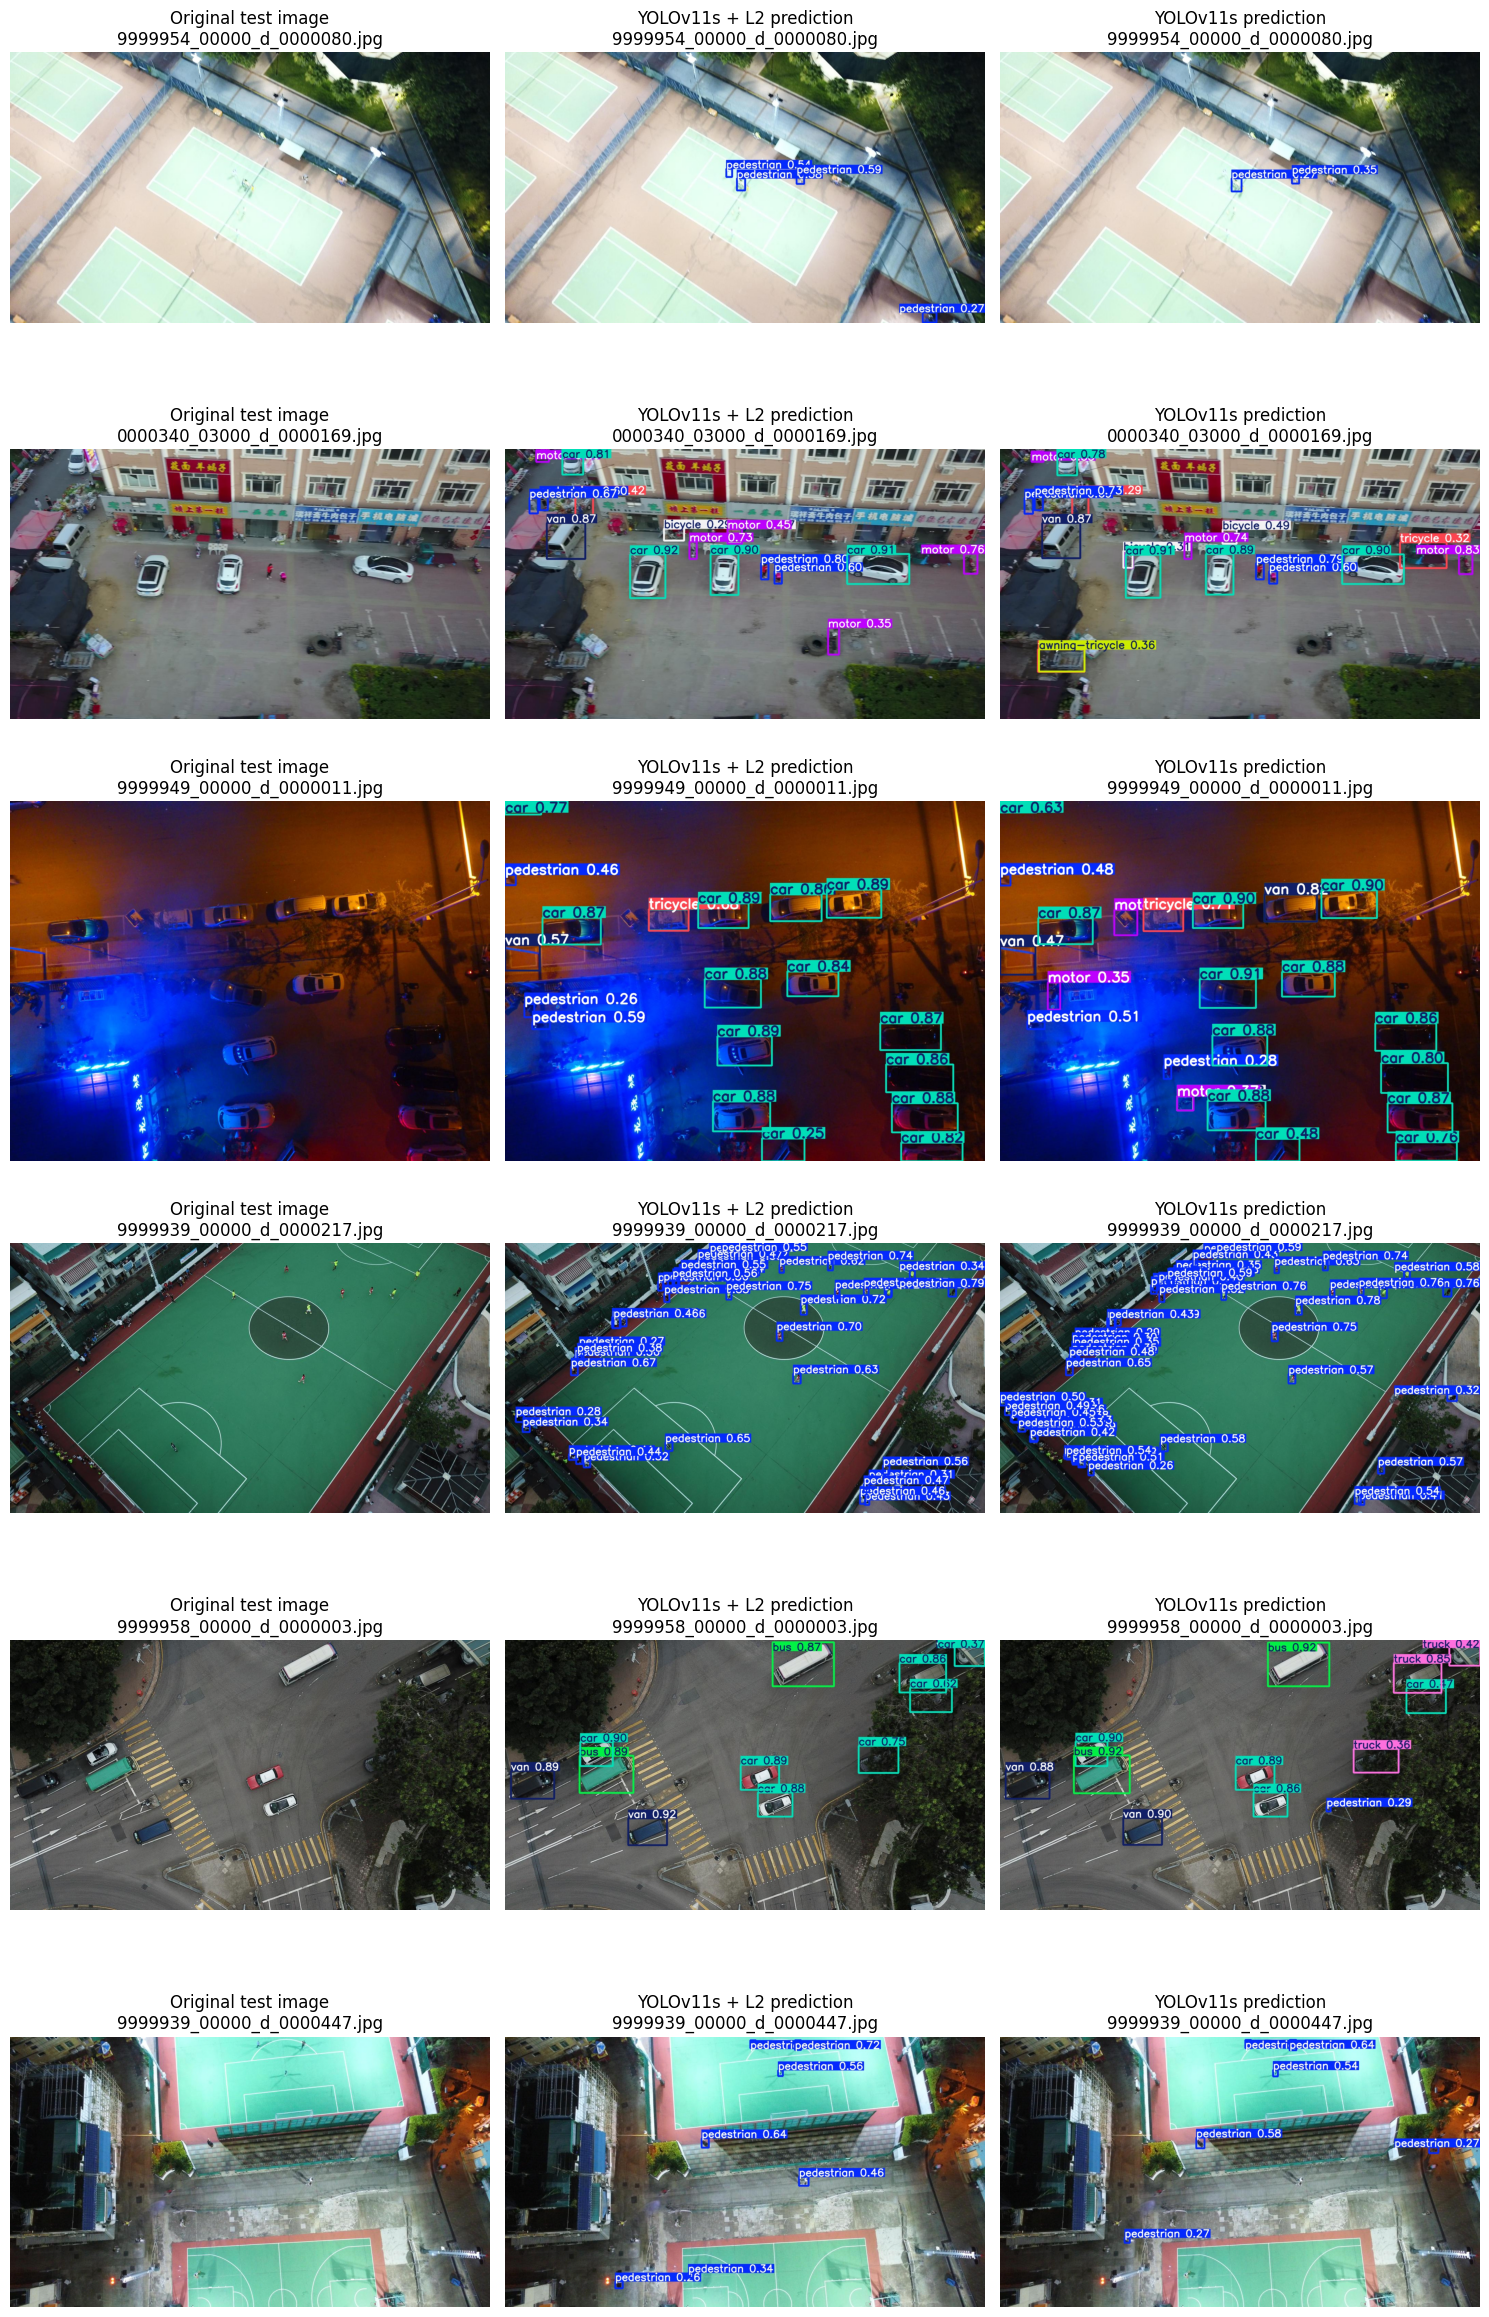

In [2]:
from pathlib import Path
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Use local project-folder paths first (repo root).
ROOT = Path.cwd().resolve()

# Resolve the test image folder from this project.
test_candidates = [
    ROOT / "VisDrone" / "VisDrone2019-DET-test-challenge" / "images",
    ROOT.parent / "VisDrone" / "VisDrone2019-DET-test-challenge" / "images",
]
test_img_dir = next((p for p in test_candidates if p.is_dir()), None)
if test_img_dir is None:
    raise FileNotFoundError("Could not find VisDrone test images under this project folder.")

# Prediction image folders written by the earlier inference cells.
l2_pred_dir = ROOT / "test_predictions_l2"
s_pred_dir = ROOT / "test_predictions_s"

all_test_images = sorted(list(test_img_dir.glob("*.jpg")) + list(test_img_dir.glob("*.png")))
if not all_test_images:
    raise FileNotFoundError(f"No test images found in: {test_img_dir}")

sample_count = min(6, len(all_test_images))
random.seed(401)
selected_images = random.sample(all_test_images, sample_count)

fig, axes = plt.subplots(sample_count, 3, figsize=(15, 4 * sample_count))
if sample_count == 1:
    axes = [axes]

for i, img_path in enumerate(selected_images):
    img_name = img_path.name
    col_axes = axes[i]

    panels = [
        (img_path, "Original test image"),
        (l2_pred_dir / img_name, "YOLOv11s + L2 prediction"),
        (s_pred_dir / img_name, "YOLOv11s prediction"),
    ]

    for ax, (panel_path, panel_title) in zip(col_axes, panels):
        ax.axis("off")
        if panel_path.exists():
            ax.imshow(mpimg.imread(panel_path))
            ax.set_title(f"{panel_title}\n{img_name}")
        else:
            ax.text(0.5, 0.5, f"{panel_title}\n(not found)", ha="center", va="center")
            ax.set_title(f"{panel_title}\n{img_name}")

plt.tight_layout()
plt.show()


## Discussion

### Observed Results on the Test-Challenge Split

The VisDrone test-challenge split does not provide public ground-truth labels inside this workflow, so we cannot compute test mAP directly in this notebook. However, we can still report useful observable outputs from inference:

| Model | Validation mAP@50 | Val-Train Gap | Test Inference Speed (ms) | Labels Exported |
|---|---:|---:|---:|---:|
| YOLOv11s + L2 | 0.4122 | 0.0384 | preprocess 2.0, inference 11.3, postprocess 1.3 | 1568 |
| YOLOv11s | 0.4135 | 0.1180 | preprocess 1.9, inference 11.2, postprocess 1.2 | 1568 |

These results show both models run at nearly identical test-time speed, while YOLOv11s + L2 has a much smaller overfitting gap.

From visual inspection of sample test images, both models perform well overall. In the second sample, YOLOv11s appears to misclassify a trolley as an awning-tricycle, but both models still detect most difficult objects reliably.

### How Accurate Is the Test Set Performance?

Because test labels are hidden, true test-set accuracy can only be measured by the official challenge evaluation score after submission. In this notebook, the best estimate of expected test behavior comes from validation quality plus generalization signals:

- YOLOv11s has a slightly higher validation mAP@50 (0.4135 vs 0.4122).
- YOLOv11s + L2 has much better generalization behavior (0.0384 vs 0.1180 gap).
- The mAP difference is small, but the overfitting-gap difference is large.

Given those points, YOLOv11s + L2 remains the safer final choice for unseen test data, even though YOLOv11s is marginally stronger on validation mAP.

### Remaining Limitations

Regardless of which model is used, the main bottleneck identified throughout this project is dataset imbalance. Classes like bicycle, tricycle, and awning-tricycle consistently show weak performance across models. This is primarily a data issue rather than an architecture issue, so collecting more annotated samples for minority classes is likely the highest-impact next step.
